**AI-Based Detection and Classification of Industrial Fires and Persistent Thermal Sources Using NASA FIRMS, OSM & Satellite Data**

In [ ]:
import pandas as pd
import numpy as np

FileNotFoundError: [Errno 2] No such file or directory: 'fire_archive_SV-C2_792675.csv'

In [ ]:
files = [
    "2021.csv",
    "2022.csv",
    "2023.csv",
    "2024.csv",
    "2025.csv"
]

In [ ]:

df3 = pd.concat(
    [pd.read_csv(f) for f in files],
    ignore_index=True
)

print(df3.shape)

In [ ]:
for i in files:
  temp = pd.read_csv(i)
  print(temp.shape)

In [ ]:
df3= pd.read_csv('2021-2025.csv')

In [ ]:
data = pd.DataFrame(df3)
data.sample(6)

In [ ]:
def extract_year(s):
  return s[:4]
print(extract_year('2024-12-06'))

2024


In [ ]:
year = data['acq_date']
year = year.apply(extract_year)

NameError: name 'data' is not defined

In [ ]:
year.sample(5)

In [ ]:
data['year'] = year

NameError: name 'year' is not defined

In [ ]:
print(data['year'].value_counts())

In [ ]:
from pyrosm import OSM
osm = OSM("india-260824.osm.pbf")

ModuleNotFoundError: No module named 'pyrosm'

In [ ]:
!!pip install osmium pandas

In [ ]:
import osmium
import pandas as pd
from shapely import wkt

industrial_locations = []

class IndustrialHandler(osmium.SimpleHandler):

    def area(self, a):

        if a.tags.get("landuse") == "industrial":

            try:
                wkt_geom = osmium.geom.WKTFactory().create_multipolygon(a)

                geom = wkt.loads(wkt_geom)

                centroid = geom.centroid

                industrial_locations.append({
                    "id": a.id,
                    "name": a.tags.get("name", ""),
                    "latitude": centroid.y,
                    "longitude": centroid.x
                })

            except Exception:
                pass

handler = IndustrialHandler()

handler.apply_file(
    "india-260824.osm.pbf",
    locations=True
)

df = pd.DataFrame(industrial_locations)

print(df.head())

df.to_csv(
    "industry_locations.csv",
    index=False
)

ModuleNotFoundError: No module named 'osmium'

In [ ]:
print(df.head())
print(df.columns)
print(len(df))

In [ ]:
df.isna().count()

In [ ]:
import pandas as pd
from scipy.spatial import cKDTree

industries = pd.read_csv("industry_locations.csv")

tree = cKDTree(
    industries[["latitude", "longitude"]].values
)

distances, _ = tree.query(
    df3[["latitude", "longitude"]].values,
    k=1
)

df3["distance_to_industry"] = distances

df3["industry_nearby"] = (
    df3["distance_to_industry"] < 0.05
).astype(int)

NameError: name 'df3' is not defined

In [ ]:
print(df3["industry_nearby"].value_counts())

In [ ]:
df3["temp_diff"] = df3["brightness"] - df3["bright_t31"]

In [ ]:
df3["lat_round"] = df3["latitude"].round(2)
df3["lon_round"] = df3["longitude"].round(2)

In [ ]:
data = pd.DataFrame(df3)
data.drop(['persistence_months_x',
 'persistence_new',
 'persistence_months',
  'persistence_months_y',
          ], axis = 1, inplace = True)

NameError: name 'df3' is not defined

In [ ]:
data.columns

In [ ]:
data["acq_date"] = pd.to_datetime(data["acq_date"])

In [ ]:
data["year"] = data["acq_date"].dt.year
data["month"] = data["acq_date"].dt.month

In [ ]:
data["persistence"].describe()

In [ ]:
freq = (
    data.groupby(["lat_round","lon_round"])
        .size()
        .reset_index(name="detection_count")
)

data = data.merge(
    freq,
    on=["lat_round","lon_round"],
    how="left"
)

In [ ]:
mapping = {
    "l": 0,
    "n": 1,
    "h": 2
}

data["confidence_num"] = (
    data["confidence"]
    .map(mapping)
)

In [ ]:
data.groupby("industry_nearby")[
    [
        "frp",
        "brightness",
        "temp_diff",
        "persistence",
        "distance_to_industry"
    ]
].mean()

NameError: name 'data' is not defined

In [ ]:
data["label"] = "other"

# Industrial persistent thermal source
data.loc[
    (data["industry_nearby"] == 1) &
    (data["persistence"] >= 100),
    "label"
] = "industrial_persistent"

# Industrial fire
data.loc[
    (data["industry_nearby"] == 1) &
    (data["persistence"] < 100) &
    (data["frp"] > data["frp"].quantile(0.9)),
    "label"
] = "industrial_fire"

In [ ]:
data.sample(5)

In [ ]:
data.groupby("industry_nearby")[
    [
        "frp",
        "brightness",
        "temp_diff",
        "persistence",
        "distance_to_industry"
    ]
].mean()

In [ ]:
data.columns.tolist()

In [ ]:
# data.to_csv('final_dataset.csv', index = False)
data2 = pd.read_csv('final_dataset.csv')
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data2["label_num"] = le.fit_transform(data2["label"])

In [ ]:
data2.sample(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,year_month,persistence,lat_round,lon_round,year,month,detection_count,confidence_num,label,label_num
1113396,22.19045,79.35721,351.03,0.45,0.39,2022-04-19,806,SNPP,SNPP,l,...,2022-04,5,22.19,79.36,2022,4,5,0,other,2
2492259,30.60021,76.42577,347.58,0.47,0.48,2024-11-01,826,SNPP,SNPP,n,...,2024-11,10,30.60,76.43,2024,11,10,1,other,2
57547,21.39871,76.20860,299.98,0.52,0.42,2021-02-12,2015,SNPP,SNPP,n,...,2021-02,2,21.40,76.21,2021,2,2,1,other,2
99894,24.35887,92.93147,339.56,0.54,0.51,2021-03-01,728,SNPP,SNPP,n,...,2021-03,13,24.36,92.93,2021,3,13,1,other,2
3067095,25.69159,93.56670,334.16,0.40,0.44,2025-05-05,717,SNPP,SNPP,n,...,2025-05,8,25.69,93.57,2025,5,8,1,other,2


In [ ]:
data2[data2['label_num'] == 0].sample(5)

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,year_month,persistence,lat_round,lon_round,year,month,detection_count,confidence_num,label,label_num
169202,20.99264,70.29309,343.65,0.46,0.47,2021-03-07,855,SNPP,SNPP,n,...,2021-03,3,20.99,70.29,2021,3,3,1,industrial_fire,0
2059428,24.55915,93.64964,343.28,0.39,0.44,2024-02-12,716,SNPP,SNPP,n,...,2024-02,14,24.56,93.65,2024,2,14,1,industrial_fire,0
1331893,30.82676,76.35981,344.14,0.47,0.48,2022-11-12,828,SNPP,SNPP,n,...,2022-11,6,30.83,76.36,2022,11,6,1,industrial_fire,0
77207,15.77437,75.07228,347.42,0.69,0.74,2021-02-24,720,SNPP,SNPP,n,...,2021-02,6,15.77,75.07,2021,2,6,1,industrial_fire,0
1812314,30.84729,74.61311,345.77,0.57,0.52,2023-05-10,733,SNPP,SNPP,n,...,2023-05,7,30.85,74.61,2023,5,7,1,industrial_fire,0


In [ ]:
data2.drop(['satellite', 'instrument', 'version', 'scan', 'track', 'year_month'], axis = 1, inplace = True)

In [ ]:
data2['scan'] = data['scan']
data2['track'] = data['track']

In [ ]:
features = [
    "brightness",
    "bright_t31",
    "frp",
    "temp_diff",

    "distance_to_industry",
    "industry_nearby",

    "persistence",
    "detection_count",
    "month",

    "scan",
    "track",

    "confidence_num"
]


In [ ]:
from sklearn.model_selection import train_test_split

X = data2[features]
y = data2["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    tree_method="hist"
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7587
           1       1.00      1.00      1.00     68936
           2       1.00      1.00      1.00    574793

    accuracy                           1.00    651316
   macro avg       1.00      1.00      1.00    651316
weighted avg       1.00      1.00      1.00    651316



In [ ]:
model.save_model("industrial_fire_model.json")

In [ ]:
importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
)

,feature,importance
5,industry_nearby,0.576387
6,persistence,0.330682
2,frp,0.092522
10,track,0.000057
9,scan,0.000055
0,brightness,0.000054
3,temp_diff,0.000054
1,bright_t31,0.000052
4,distance_to_industry,0.000050
8,month,0.000047


In [ ]:
feat2 = ["brightness",
"bright_t31",
"frp",
"temp_diff",
"scan",
"track",
"month",
"confidence_num"]

feat3 = ["brightness",
"bright_t31",
"frp",
"temp_diff",
"scan",
"track",
"month",
"confidence_num",
'distance_to_industry',
 'industry_nearby',]


In [ ]:
from sklearn.model_selection import train_test_split

X = data2[feat2]
y = data2["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model2 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    tree_method="hist"
)

model2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred1 = model2.predict(X_test)
print(classification_report(y_test, pred1))

              precision    recall  f1-score   support

           0       0.62      0.02      0.05      7587
           1       0.76      0.55      0.64     68936
           2       0.94      0.98      0.96    574793

    accuracy                           0.92    651316
   macro avg       0.77      0.52      0.55    651316
weighted avg       0.91      0.92      0.91    651316



In [ ]:
from sklearn.model_selection import train_test_split

X = data2[feat3]
y = data2["label_num"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model3 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    tree_method="hist"
)

model3.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred2 = model3.predict(X_test)
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      7587
           1       0.85      0.88      0.86     68936
           2       0.99      0.98      0.98    574793

    accuracy                           0.97    651316
   macro avg       0.93      0.95      0.94    651316
weighted avg       0.97      0.97      0.97    651316



In [ ]:
import pickle

with open("industrial_fire_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

In [ ]:
lookup = (
    data2
    .groupby(["lat_round", "lon_round"])
    .agg(
        persistence=("persistence", "max"),
        detection_count=("latitude", "count")
    )
    .reset_index()
)

In [ ]:
lookup.sample(5)

In [ ]:
history_dict = {
    (row.lat_round, row.lon_round): (
        row.persistence,
        row.detection_count
    )
    for _, row in lookup.iterrows()
}

In [ ]:
import pickle

with open("history_lookup.pkl", "wb") as f:
    pickle.dump(history_dict, f)

print("Saved!")

**FEATURE EXTRACTION AND PREDICTING**

In [ ]:
import pickle
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
from xgboost import XGBClassifier

# persistence lookup
with open("history_lookup.pkl", "rb") as f:
    history_dict = pickle.load(f)



# industries
industry_df = pd.read_csv("industry_locations.csv")

industry_tree = BallTree(
    np.radians(industry_df[["latitude", "longitude"]]),
    metric="haversine"
)


In [ ]:
def generate_features(firms_data):

    lat = firms_data["latitude"]
    lon = firms_data["longitude"]

    # ----------------------------------
    # temp_diff
    # ----------------------------------
    temp_diff = (
        firms_data["brightness"]
        - firms_data["bright_t31"]
    )

    # ----------------------------------
    # nearest industry
    # ----------------------------------
    point = np.radians([[lat, lon]])

    dist, idx = industry_tree.query(
        point,
        k=1
    )

    distance_to_industry = (
        dist[0][0] * 6371
    )

    industry_nearby = int(
        distance_to_industry <= 5
    )

    # ----------------------------------
    # persistence + detection count
    # ----------------------------------
    persistence, detection_count = (
        history_dict.get(
            (
                round(lat, 2),
                round(lon, 2)
            ),
            (1, 1)
        )
    )

    # ----------------------------------
    # month
    # ----------------------------------
    month = pd.to_datetime(
        firms_data["acq_date"]
    ).month

    # ----------------------------------
    # confidence
    # ----------------------------------
    confidence_map = {
        "l": 0,
        "n": 1,
        "h": 2
    }

    confidence_num = confidence_map.get(
        str(
            firms_data["confidence"]
        ).lower(),
        1
    )

    # ----------------------------------
    # model dataframe
    # ----------------------------------
    X = pd.DataFrame([{
        "brightness":
            firms_data["brightness"],

        "bright_t31":
            firms_data["bright_t31"],

        "frp":
            firms_data["frp"],

        "temp_diff":
            temp_diff,

        "distance_to_industry":
            distance_to_industry,

        "industry_nearby":
            industry_nearby,

        "persistence":
            persistence,

        "detection_count":
            detection_count,

        "month":
            month,

        "scan":
            firms_data["scan"],

        "track":
            firms_data["track"],

        "confidence_num":
            confidence_num
    }])

    return X

In [ ]:
#random data from dataset for testing
firms_data = pd.DataFrame([{
    "latitude": 25.32909,
    "longitude": 94.71902,
    "brightness": 330.71,
    "scan": 0.62,
    "track": 0.71,
    "acq_date": "2021-01-01",
    "acq_time": 554,
    "satellite": "SNPP",
    "instrument": "SNPP",
    "confidence": "n",
    "version": 2,
    "bright_t31": 289.06,
    "frp": 6.72,
    "daynight": "D",
    "type": 0
}])

print(firms_data.head())


   latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0  25.32909   94.71902      330.71  0.62   0.71  2021-01-01       554   

  satellite instrument confidence  version  bright_t31   frp daynight  type  
0      SNPP       SNPP          n        2      289.06  6.72        D     0  


In [ ]:
x = generate_features(firms_data.iloc[0].to_dict())

NameError: name 'generate_features' is not defined

,brightness,bright_t31,frp,temp_diff,distance_to_industry,industry_nearby,persistence,detection_count,month,scan,track,confidence_num
0,330.71,289.06,6.72,41.65,69.627129,0,7.0,7.0,1,0.62,0.71,1


In [ ]:
model.predict(x)

NameError: name 'model_testing' is not defined

In [ ]:
import matplotlib.pyplot as plt

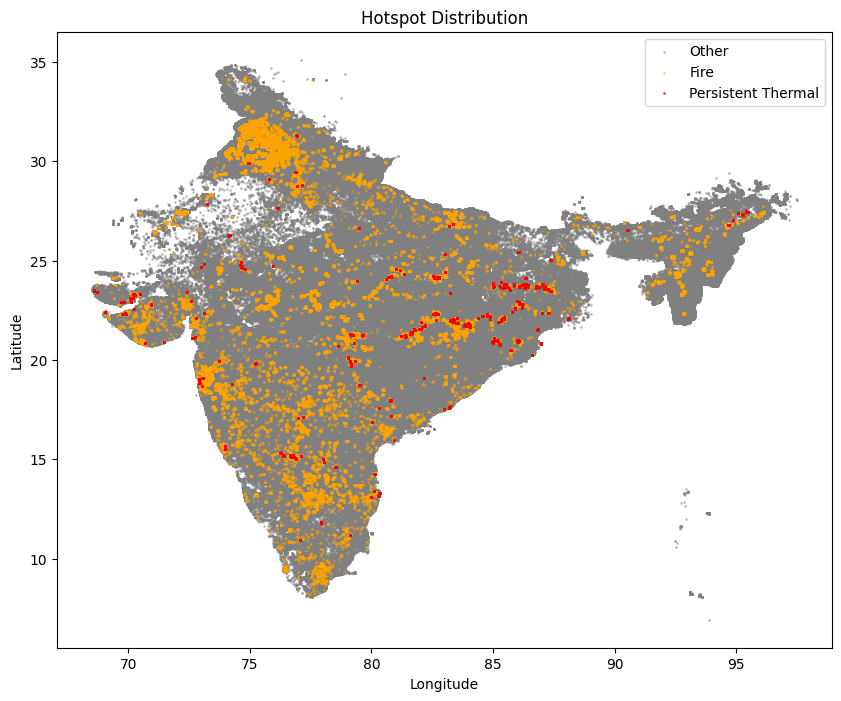

In [ ]:
fire = data2[data2["label"] == "industrial_fire"]
thermal = data2[data2["label"] == "industrial_persistent"]
other = data2[data2["label"] == "other"]

plt.figure(figsize=(10, 8))
# Other
plt.scatter(
    other["longitude"],
    other["latitude"],
    s=1,
    alpha=0.4,
    color="gray",
    label="Other"
)

# Fire
plt.scatter(
    fire["longitude"],
    fire["latitude"],
    s=1,
    alpha=0.4,
    color="orange",
    label="Fire"
)

# Persistent Thermal Source
plt.scatter(
    thermal["longitude"],
    thermal["latitude"],
    s=1,
    alpha=0.6,
    color="red",
    label="Persistent Thermal"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Hotspot Distribution")
plt.legend()
plt.show()

In [ ]:
# print(thermal.shape, fire.shape, other.shape)
print(data2['label'].value_counts())

label
other                    2873964
industrial_persistent     344678
industrial_fire            37934
Name: count, dtype: int64


In [ ]:
fire.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,year_month,persistence,lat_round,lon_round,year,month,detection_count,confidence_num,label,label_num
25,16.57542,80.57591,367.00,0.56,0.43,2021-01-01,732,SNPP,SNPP,h,...,2021-01,2,16.58,80.58,2021,1,2,2,industrial_fire,0
120,17.62053,73.47224,367.00,0.50,0.66,2021-01-01,733,SNPP,SNPP,h,...,2021-01,9,17.62,73.47,2021,1,9,2,industrial_fire,0
121,17.61952,73.46751,337.11,0.50,0.66,2021-01-01,733,SNPP,SNPP,n,...,2021-01,9,17.62,73.47,2021,1,9,1,industrial_fire,0
123,17.62109,73.47329,367.00,0.50,0.66,2021-01-01,733,SNPP,SNPP,h,...,2021-01,9,17.62,73.47,2021,1,9,2,industrial_fire,0
124,17.62005,73.46858,356.45,0.50,0.66,2021-01-01,733,SNPP,SNPP,n,...,2021-01,9,17.62,73.47,2021,1,9,1,industrial_fire,0
